# Project_Dacian_Rares

## Bus Schedule Optimization using Genetic Algorithm and Hybrid Genetic Algorithm with Simulated Annealing

**Metaheuristics project, final form for Week 11 and Week 12**

Team topic: **Public Transport Timetabling / Bus Schedule Optimization**.  
Main question: **when should the buses depart so that passengers wait less, buses are not overcrowded, and the timetable stays operationally realistic?**

The two required project methods are:

1. **Genetic Algorithm (GA)**.
2. **Hybrid GA + SA**, where **Simulated Annealing is used as the mutation/local-refinement operator inside the GA**.

For the Week 12 comparison, the two selected methods are compared with:

3. **Particle Swarm Optimization (PSO)**.
4. **Whale Optimization Algorithm (WOA)**.
5. **Puma Optimization Algorithm (POA)**.


## 1. Problem Definition

We optimize the departure times of buses for one urban route during a 16-hour operating day, from **06:00 to 22:00**.

A candidate timetable is represented by a vector:

`x = [departure_1, departure_2, ..., departure_n]`

where each departure is a minute after 06:00. The vector is repaired into a feasible timetable by sorting it and enforcing a minimum gap between consecutive buses.

The optimization objective combines four practical costs:

- **Passenger waiting time**: high when a large passenger demand interval has a long headway.
- **Crowding penalty**: high when passenger demand between two buses exceeds bus capacity.
- **Regularity penalty**: discourages very unstable headways.
- **Coverage penalty**: discourages large uncovered time at the beginning or end of the day.

This gives a realistic public-transport timetabling model without requiring a private city dataset.


## 2. Related Work

The project requirement asks for recent scientific work related to the selected optimization problem.

The main reference used here is:

> Suanpang, P., Jamjuntr, P., Jermsittiparsert, K., & Kaewyong, P. (2022). *Tourism Service Scheduling in Smart City Based on Hybrid Genetic Algorithm Simulated Annealing Algorithm*. Sustainability, 14(23), 16293. https://doi.org/10.3390/su142316293

The paper uses a hybrid Genetic Algorithm and Simulated Annealing approach for a scheduling problem in a smart-city service context. The useful ideas for this bus timetabling project are:

- represent a schedule as an encoded chromosome;
- evaluate each chromosome with a fitness function;
- use elitism and selection to preserve good schedules;
- use crossover to recombine existing schedules;
- use Simulated Annealing neighborhood moves to refine schedules and escape local optima.

The notebook adapts those ideas to bus departure-time optimization. The hybrid method is not implemented as a separate final SA pass only; instead, SA is used as the mutation/refinement operator for GA offspring, which matches the chosen project idea.


In [11]:
import math
import random
import time
from dataclasses import dataclass
from typing import Callable, Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")


## 3. Dataset

The dataset uses real transportation data from the `hourly_transportation_202001.csv` dataset, specifically filtered for January 1st, 2020, and bus line 429A. The raw data provides hourly passenger counts, which we distribute evenly across each minute of the respective hour.

- operating period: 06:00-22:00;
- variable hourly demand based on real passenger tap-ins;
- a fixed bus capacity.


In [12]:
import pandas as pd
import numpy as np

DAY_MINUTES = 16 * 60
START_HOUR = 6
N_BUSES = 200
BUS_CAPACITY = 55
MIN_GAP = 2
MAX_GAP_SOFT = 45

def minutes_to_clock(minute_after_start: float) -> str:
    total = int(round(START_HOUR * 60 + minute_after_start))
    return f"{(total // 60) % 24:02d}:{total % 60:02d}"

# Load and filter the dataset
df_raw = pd.read_csv('hourly_transportation_202001.csv', encoding='ISO-8859-1')
df_filtered = df_raw[(df_raw['transition_date'] == '1/1/2020') & (df_raw['line_name'] == '429A')]

# Group by hour to get the total passenger demand per hour
hourly_demand = df_filtered.groupby('transition_hour')['number_of_passenger'].sum().reset_index()

minute_grid = np.arange(DAY_MINUTES + 1)
demand = np.zeros_like(minute_grid, dtype=int)

for hour in range(6, 22):
    hour_data = hourly_demand[hourly_demand['transition_hour'] == hour]
    if not hour_data.empty:
        passengers = int(hour_data.iloc[0]['number_of_passenger'])
    else:
        passengers = 0
        
    # Distribute passengers evenly into an array of integers of size 60
    dist = [passengers // 60] * 60
    remainder = passengers % 60
    if remainder > 0:
        step = 60 / remainder
        for i in range(remainder):
            dist[int(i * step)] += 1
            
    start_min = (hour - 6) * 60
    end_min = (hour - 5) * 60
    
    demand[start_min:end_min] = dist

demand_df = pd.DataFrame(
    {
        "minute": minute_grid,
        "time": [minutes_to_clock(m) for m in minute_grid],
        "passengers_per_minute": demand,
    }
)

demand_df.head(60)


,minute,time,passengers_per_minute
0,0,06:00,5
1,1,06:01,4
2,2,06:02,5
3,3,06:03,4
4,4,06:04,5
5,5,06:05,4
6,6,06:06,5
7,7,06:07,4
8,8,06:08,5
9,9,06:09,4


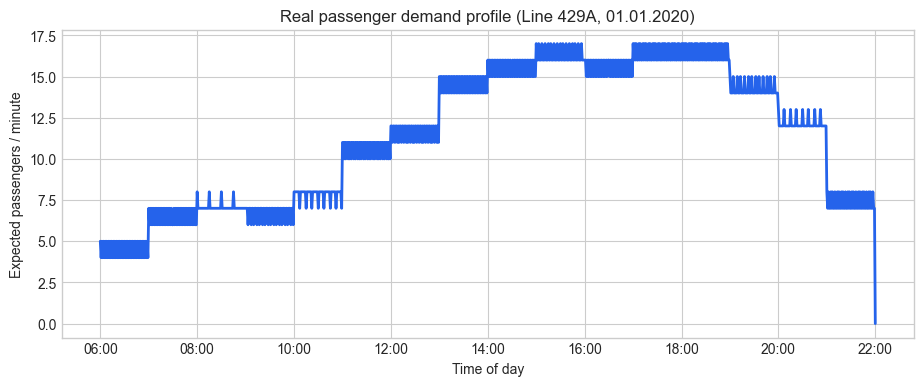

In [13]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(demand_df["minute"], demand_df["passengers_per_minute"], color="#2563eb", linewidth=2)
ax.set_title("Real passenger demand profile (Line 429A, 01.01.2020)")
ax.set_xlabel("Time of day")
ax.set_ylabel("Expected passengers / minute")
ticks = np.arange(0, DAY_MINUTES + 1, 120)
ax.set_xticks(ticks)
ax.set_xticklabels([minutes_to_clock(t) for t in ticks])
plt.show()


## 4. Objective Function

For each interval between two consecutive buses, passenger arrivals are approximated by integrating the demand curve. If the headway is long and demand is high, passengers wait more.

For an interval with length `h` and total passenger demand `D`, the expected waiting cost is:

`D * h / 2`

The final minimization objective is:

`objective = waiting_cost + crowding_penalty + regularity_penalty + coverage_penalty`

Lower is better.


In [ ]:
def repair_schedule(x: np.ndarray, n_buses: int = N_BUSES, min_gap: int = MIN_GAP) -> np.ndarray:
    # Sort and clip a candidate into a feasible fixed-length departure timetable.
    y = np.array(x, dtype=float).copy()
    if y.size != n_buses:
        y = np.resize(y, n_buses)
    y = np.clip(y, 0, DAY_MINUTES)
    y.sort()

    for i in range(1, n_buses):
        if y[i] < y[i - 1] + min_gap:
            y[i] = y[i - 1] + min_gap

    overflow = y[-1] - DAY_MINUTES
    if overflow > 0:
        y -= overflow
        y[0] = max(0, y[0])
        for i in range(1, n_buses):
            y[i] = max(y[i], y[i - 1] + min_gap)

    return np.clip(y, 0, DAY_MINUTES)


def interval_demand(a: float, b: float) -> float:
    a_i = max(0, min(DAY_MINUTES, int(round(a))))
    b_i = max(0, min(DAY_MINUTES, int(round(b))))
    if b_i <= a_i:
        return 0.0
    return float(np.trapz(demand[a_i : b_i + 1], dx=1))


def objective(schedule: np.ndarray, details: bool = False):
    s = repair_schedule(schedule)
    boundaries = np.concatenate(([0.0], s, [float(DAY_MINUTES)]))
    headways = np.diff(boundaries)

    waiting_cost = 0.0
    crowding_penalty = 0.0
    max_gap_penalty = 0.0

    for a, b, h in zip(boundaries[:-1], boundaries[1:], headways):
        D = interval_demand(a, b)
        waiting_cost += D * h / 2.0
        overload = max(0.0, D - BUS_CAPACITY)
        crowding_penalty += 20.0 * overload**2
        max_gap_penalty += 80.0 * max(0.0, h - MAX_GAP_SOFT) ** 2

    operational_headways = np.diff(s)
    regularity_penalty = 4.0 * float(np.var(operational_headways))
    coverage_penalty = 25.0 * (s[0] ** 1.35 + (DAY_MINUTES - s[-1]) ** 1.35)

    total = waiting_cost + crowding_penalty + regularity_penalty + coverage_penalty + max_gap_penalty
    if details:
        return {
            "total": total,
            "waiting": waiting_cost,
            "crowding": crowding_penalty,
            "regularity": regularity_penalty,
            "coverage": coverage_penalty,
            "max_gap": max_gap_penalty,
            "mean_headway": float(np.mean(operational_headways)),
            "max_headway": float(np.max(headways)),
        }
    return total


def random_schedule(rng: np.random.Generator) -> np.ndarray:
    base = np.linspace(5, DAY_MINUTES - 5, N_BUSES)
    noise = rng.normal(0, 18, size=N_BUSES)
    return repair_schedule(base + noise)


baseline_even = repair_schedule(np.linspace(5, DAY_MINUTES - 5, N_BUSES))
objective(baseline_even, details=True)


{'total': 709785.5534371661,
 'waiting': 26237.43718592966,
 'crowding': 683109.0,
 'regularity': 6.085074816617292e-27,
 'coverage': 439.1162512365069,
 'max_gap': 0.0,
 'mean_headway': 4.773869346733668,
 'max_headway': 5.0}

## 5. Week 11: Proposed Metaheuristics

### 5.1 Simple Genetic Algorithm (GA)

Main steps:

1. Generate an initial population of random but repaired timetables.
2. Evaluate all individuals with the objective function.
3. Keep the elite schedules.
4. Select parents using tournament selection.
5. Create children using arithmetic crossover.
6. Mutate children by randomly shifting one or more departures.
7. Repair every child to maintain timetable feasibility.
8. Repeat for a fixed number of generations.

### 5.2 Hybrid GA + Simulated Annealing (Post-Optimization)

Instead of applying SA inside the GA loop as a mutation operator, this hybrid algorithm separates the two phases:

1. First, the Simple GA runs to completion to find a strong global solution.
2. Then, the single best schedule found by the GA is extracted.
3. This schedule is passed through an intensive Simulated Annealing (SA) phase to perform local refinement.
4. The SA accepts improvements directly, and accepts worse moves with probability `exp(-delta / temperature)`, slowly cooling the temperature.

This structure allows the GA to efficiently explore the global search space, and the SA to heavily exploit the best promising region.


In [15]:
@dataclass
class RunResult:
    name: str
    best_schedule: np.ndarray
    best_score: float
    history: List[float]
    runtime: float


def tournament_select(population: List[np.ndarray], scores: np.ndarray, rng: np.random.Generator, k: int = 3) -> np.ndarray:
    idx = rng.choice(len(population), size=k, replace=False)
    return population[int(idx[np.argmin(scores[idx])])].copy()


def crossover(p1: np.ndarray, p2: np.ndarray, rng: np.random.Generator, crossover_rate: float = 0.5) -> np.ndarray:
    if rng.random() > crossover_rate:
        return p1.copy() if rng.random() < 0.5 else p2.copy()
        
    alpha = rng.uniform(0.25, 0.75, size=N_BUSES)
    child = alpha * p1 + (1.0 - alpha) * p2
    if rng.random() < 0.5:
        cut = rng.integers(1, N_BUSES - 1)
        child[:cut] = p1[:cut]
        child[cut:] = p2[cut:]
    return repair_schedule(child)


def gaussian_mutation(child: np.ndarray, rng: np.random.Generator, mutation_rate: float = 0.22, sigma: float = 16.0) -> np.ndarray:
    y = child.copy()
    mask = rng.random(N_BUSES) < mutation_rate
    if not np.any(mask):
        mask[rng.integers(0, N_BUSES)] = True
    y[mask] += rng.normal(0, sigma, size=np.sum(mask))
    return repair_schedule(y)


def neighbor(schedule: np.ndarray, rng: np.random.Generator, scale: float = 12.0) -> np.ndarray:
    y = schedule.copy()
    if rng.random() < 0.75:
        i = rng.integers(0, N_BUSES)
        y[i] += rng.normal(0, scale)
    else:
        i = rng.integers(0, N_BUSES - 2)
        j = min(N_BUSES, i + rng.integers(2, 7))
        y[i:j] += rng.normal(0, scale / 2.0)
    return repair_schedule(y)


def run_sa(initial_schedule: np.ndarray, rng: np.random.Generator, steps: int = 1000, t0: float = 220.0, cooling: float = 0.99) -> np.ndarray:
    current = repair_schedule(initial_schedule)
    current_score = objective(current)
    best = current.copy()
    best_score = current_score
    T = t0
    for _ in range(steps):
        candidate = neighbor(current, rng, scale=max(3.0, T / 18.0))
        candidate_score = objective(candidate)
        delta = candidate_score - current_score
        if delta <= 0 or rng.random() < math.exp(-delta / max(T, 1e-9)):
            current = candidate
            current_score = candidate_score
            if current_score < best_score:
                best = current.copy()
                best_score = current_score
        T *= cooling
    return best


def run_ga(
    seed: int,
    population_size: int = 46,
    generations: int = 90,
    elite_size: int = 4,
    crossover_rate: float = 0.5,
    mutation_rate: float = 0.22
) -> RunResult:
    rng = np.random.default_rng(seed)
    start = time.perf_counter()
    population = [random_schedule(rng) for _ in range(population_size)]
    history = []

    for _ in range(generations):
        scores = np.array([objective(ind) for ind in population])
        order = np.argsort(scores)
        new_population = [population[i].copy() for i in order[:elite_size]]

        while len(new_population) < population_size:
            p1 = tournament_select(population, scores, rng)
            p2 = tournament_select(population, scores, rng)
            child = crossover(p1, p2, rng, crossover_rate=crossover_rate)
            child = gaussian_mutation(child, rng, mutation_rate=mutation_rate)
            new_population.append(child)

        population = new_population
        history.append(float(scores[order[0]]))

    scores = np.array([objective(ind) for ind in population])
    best_idx = int(np.argmin(scores))
    return RunResult(
        name="Simple GA",
        best_schedule=population[best_idx],
        best_score=float(scores[best_idx]),
        history=history,
        runtime=time.perf_counter() - start,
    )


def run_hybrid_ga_sa(
    seed: int,
    population_size: int = 46,
    generations: int = 90,
    elite_size: int = 4,
    crossover_rate: float = 0.5,
    mutation_rate: float = 0.22,
    sa_steps: int = 1000,
    sa_t0: float = 220.0,
    sa_cooling: float = 0.99
) -> RunResult:
    
    ga_result = run_ga(
        seed=seed,
        population_size=population_size,
        generations=generations,
        elite_size=elite_size,
        crossover_rate=crossover_rate,
        mutation_rate=mutation_rate
    )
    
    rng = np.random.default_rng(seed + 999)
    start_sa = time.perf_counter()
    
    best_sa_schedule = run_sa(
        initial_schedule=ga_result.best_schedule,
        rng=rng,
        steps=sa_steps,
        t0=sa_t0,
        cooling=sa_cooling
    )
    
    final_score = objective(best_sa_schedule)
    total_runtime = ga_result.runtime + (time.perf_counter() - start_sa)
    
    return RunResult(
        name="Hybrid GA + SA",
        best_schedule=best_sa_schedule,
        best_score=final_score,
        history=ga_result.history + [final_score],
        runtime=total_runtime
    )


## 6. Week 12: Additional Algorithms for Comparison

The comparison algorithms are continuous population methods. Their candidate vectors are repaired into valid bus timetables before evaluation.

- **PSO**: particles move using personal best and global best schedules.
- **WOA**: whales update around the current best solution using encircling and spiral moves.
- **POA**: pumas alternate between exploration around the population and exploitation around the current best.


In [16]:
def run_pso(seed: int, particles: int = 42, iterations: int = 90) -> RunResult:
    rng = np.random.default_rng(seed)
    start = time.perf_counter()
    X = np.array([random_schedule(rng) for _ in range(particles)])
    V = rng.normal(0, 8, size=X.shape)
    P = X.copy()
    P_scores = np.array([objective(x) for x in X])
    gbest = P[int(np.argmin(P_scores))].copy()
    gbest_score = float(np.min(P_scores))
    history = []

    w, c1, c2 = 0.72, 1.45, 1.45
    for _ in range(iterations):
        r1 = rng.random(X.shape)
        r2 = rng.random(X.shape)
        V = w * V + c1 * r1 * (P - X) + c2 * r2 * (gbest - X)
        X = np.array([repair_schedule(x + v) for x, v in zip(X, V)])
        scores = np.array([objective(x) for x in X])
        improved = scores < P_scores
        P[improved] = X[improved]
        P_scores[improved] = scores[improved]
        if float(np.min(P_scores)) < gbest_score:
            gbest = P[int(np.argmin(P_scores))].copy()
            gbest_score = float(np.min(P_scores))
        history.append(gbest_score)

    return RunResult("PSO", gbest, gbest_score, history, time.perf_counter() - start)


def run_woa(seed: int, whales: int = 42, iterations: int = 90) -> RunResult:
    rng = np.random.default_rng(seed)
    start = time.perf_counter()
    X = np.array([random_schedule(rng) for _ in range(whales)])
    scores = np.array([objective(x) for x in X])
    best = X[int(np.argmin(scores))].copy()
    best_score = float(np.min(scores))
    history = []

    for t in range(iterations):
        a = 2 - 2 * (t / max(1, iterations - 1))
        for i in range(whales):
            r = rng.random(N_BUSES)
            A = 2 * a * r - a
            C = 2 * rng.random(N_BUSES)
            p = rng.random()
            if p < 0.5:
                if np.mean(np.abs(A)) < 1:
                    D = np.abs(C * best - X[i])
                    candidate = best - A * D
                else:
                    rand = X[rng.integers(0, whales)]
                    D = np.abs(C * rand - X[i])
                    candidate = rand - A * D
            else:
                D = np.abs(best - X[i])
                l = rng.uniform(-1, 1, size=N_BUSES)
                candidate = D * np.exp(0.8 * l) * np.cos(2 * np.pi * l) + best
            X[i] = repair_schedule(candidate)

        scores = np.array([objective(x) for x in X])
        if float(np.min(scores)) < best_score:
            best = X[int(np.argmin(scores))].copy()
            best_score = float(np.min(scores))
        history.append(best_score)

    return RunResult("WOA", best, best_score, history, time.perf_counter() - start)


def run_poa(seed: int, pumas: int = 42, iterations: int = 90) -> RunResult:
    # Compact puma-inspired optimizer: exploration by roaming, exploitation around the best.
    rng = np.random.default_rng(seed)
    start = time.perf_counter()
    X = np.array([random_schedule(rng) for _ in range(pumas)])
    scores = np.array([objective(x) for x in X])
    best = X[int(np.argmin(scores))].copy()
    best_score = float(np.min(scores))
    history = []

    for t in range(iterations):
        progress = t / max(1, iterations - 1)
        exploration_strength = 1.0 - progress
        exploitation_strength = progress
        center = np.mean(X, axis=0)

        for i in range(pumas):
            if rng.random() < exploration_strength:
                peer = X[rng.integers(0, pumas)]
                jump = rng.normal(0, 20 * exploration_strength, size=N_BUSES)
                candidate = X[i] + rng.random(N_BUSES) * (peer - center) + jump
            else:
                stalk = rng.random(N_BUSES) * (best - X[i])
                short_jump = rng.normal(0, 5 * (1 - exploitation_strength + 0.1), size=N_BUSES)
                candidate = X[i] + stalk + short_jump

            candidate = repair_schedule(candidate)
            candidate_score = objective(candidate)
            if candidate_score < scores[i] or rng.random() < 0.03 * exploration_strength:
                X[i] = candidate
                scores[i] = candidate_score

        if float(np.min(scores)) < best_score:
            best = X[int(np.argmin(scores))].copy()
            best_score = float(np.min(scores))
        history.append(best_score)

    return RunResult("POA", best, best_score, history, time.perf_counter() - start)


## 7. Parameter Validation

We run an extensive grid search to validate our parameter choices. First, we test 54 combinations of GA parameters (Population Size, Generations, Mutation Rate, Crossover Rate).

Then, we take the best GA schedule and use it to test 27 combinations of Simulated Annealing parameters (Steps, Initial Temperature, Cooling Rate).


In [17]:
import itertools
from IPython.display import display

ga_pop_sizes = [30, 50, 100]
ga_generations = [50, 100]
ga_mut_rates = [0.1, 0.22, 0.5]
ga_cross_rates = [0.5, 0.7, 0.9]

combinations = list(itertools.product(ga_pop_sizes, ga_generations, ga_mut_rates, ga_cross_rates))
print(f"Total GA combinations to test: {len(combinations)}")

ga_validation_rows = []
# Using 1 fixed seed for tuning to ensure a fair comparison and reasonable runtime.
seeds_to_test = [42]

for pop, gen, mut, cross in combinations:
    scores = []
    runtimes = []
    
    for seed in seeds_to_test:
        res = run_ga(
            seed=seed, 
            population_size=pop, 
            generations=gen, 
            mutation_rate=mut, 
            crossover_rate=cross
        )
        scores.append(res.best_score)
        runtimes.append(res.runtime)
        
    ga_validation_rows.append({
        "population": pop,
        "generations": gen,
        "mutation_rate": mut,
        "crossover_rate": cross,
        "mean_score": np.mean(scores),
        "mean_runtime_sec": np.mean(runtimes),
    })

ga_validation_df = pd.DataFrame(ga_validation_rows).sort_values("mean_score")
display(ga_validation_df.head(10))


Total GA combinations to test: 54


,population,generations,mutation_rate,crossover_rate,mean_score,mean_runtime_sec
29,50,100,0.1,0.9,1.627861e+06,11.255672
20,50,50,0.1,0.9,1.662159e+06,5.818256
2,30,50,0.1,0.9,1.663424e+06,15.588952
11,30,100,0.1,0.9,1.663424e+06,6.743958
47,100,100,0.1,0.9,1.700847e+06,22.746135
38,100,50,0.1,0.9,1.700847e+06,11.588649
28,50,100,0.1,0.7,1.727848e+06,11.236324
37,100,50,0.1,0.7,1.751785e+06,11.954723
46,100,100,0.1,0.7,1.751785e+06,22.979621
45,100,100,0.1,0.5,1.757575e+06,22.568145


In [18]:
# 1. Extract the best GA parameters from the grid search
best_ga_params = ga_validation_df.iloc[0]
print("Best GA Parameters:")
print(best_ga_params)

# 2. Re-run GA to get the base schedule for SA testing
best_ga_res = run_ga(
    seed=42,
    population_size=int(best_ga_params["population"]),
    generations=int(best_ga_params["generations"]),
    mutation_rate=best_ga_params["mutation_rate"],
    crossover_rate=best_ga_params["crossover_rate"]
)
base_schedule = best_ga_res.best_schedule
base_score = best_ga_res.best_score
print(f"\nBase GA Score for SA Testing: {base_score:.2f}")

# 3. Setup SA grid search
sa_steps_list = [200, 500, 1000]
sa_t0_list = [100.0, 200.0, 500.0]
sa_cooling_list = [0.90, 0.95, 0.99]

sa_combinations = list(itertools.product(sa_steps_list, sa_t0_list, sa_cooling_list))
print(f"\nTotal SA combinations to test: {len(sa_combinations)}")

sa_validation_rows = []

for steps, t0, cooling in sa_combinations:
    # We test SA multiple times since it's highly stochastic
    sa_scores = []
    sa_runtimes = []
    
    for i in range(3):
        start_run = time.perf_counter()
        sa_schedule = run_sa(
            initial_schedule=base_schedule,
            rng=np.random.default_rng(100 + i), # 3 different random seeds
            steps=steps,
            t0=t0,
            cooling=cooling
        )
        sa_scores.append(objective(sa_schedule))
        sa_runtimes.append(time.perf_counter() - start_run)
        
    sa_validation_rows.append({
        "steps": steps,
        "t0": t0,
        "cooling": cooling,
        "mean_score": np.mean(sa_scores),
        "min_score": np.min(sa_scores),
        "mean_runtime_sec": np.mean(sa_runtimes),
    })

sa_validation_df = pd.DataFrame(sa_validation_rows).sort_values("mean_score")
display(sa_validation_df.head(10))


Best GA Parameters:
population          5.000000e+01
generations         1.000000e+02
mutation_rate       1.000000e-01
crossover_rate      9.000000e-01
mean_score          1.627861e+06
mean_runtime_sec    1.125567e+01
Name: 29, dtype: float64

Base GA Score for SA Testing: 1627860.99

Total SA combinations to test: 27


,steps,t0,cooling,mean_score,min_score,mean_runtime_sec
23,1000,200.0,0.99,9.135435e+05,8.544264e+05,2.154331
21,1000,200.0,0.90,9.146636e+05,8.944738e+05,2.144254
20,1000,100.0,0.99,9.294435e+05,9.068622e+05,2.178673
19,1000,100.0,0.95,9.423617e+05,9.052102e+05,2.185372
22,1000,200.0,0.95,9.447583e+05,8.952822e+05,2.134403
18,1000,100.0,0.90,9.630172e+05,9.360569e+05,2.300014
26,1000,500.0,0.99,9.758150e+05,9.606525e+05,2.160195
24,1000,500.0,0.90,1.000057e+06,9.272735e+05,2.197708
25,1000,500.0,0.95,1.002819e+06,8.935527e+05,2.227854
13,500,200.0,0.95,1.094124e+06,1.054177e+06,1.120385


## 7.1 Statistical Comparison (30 Runs)

We now run the Simple GA and Hybrid GA + SA 30 times using their optimal parameters found above to perform a statistical comparison. To maintain the standard seed progression used throughout the experiments (e.g. 101, 202, 303...), we generate 30 seeds following the same pattern.

Running 30 iterations for both algorithms... This may take a minute or two.

--- Simple GA ---
Mean: 1701542.77 | Min: 1542622.86 | Max: 1843194.06
--- Hybrid GA + SA ---
Mean: 1001775.24 | Min: 871023.11 | Max: 1136937.96


C:\Users\rares\AppData\Local\Temp\ipykernel_27508\2017172399.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([ga_scores, hybrid_scores], labels=["Simple GA", "Hybrid GA + SA"])


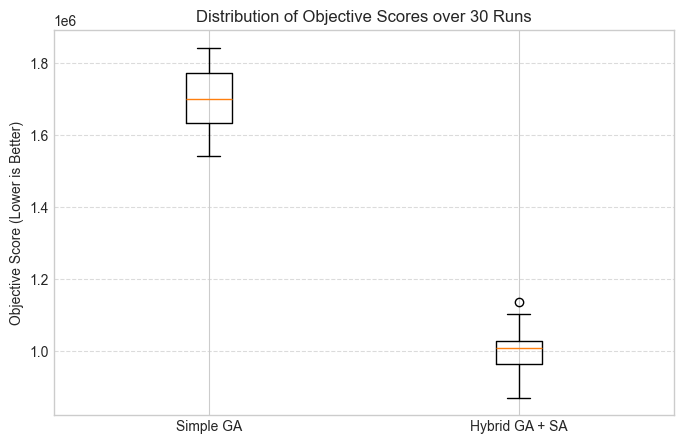

In [19]:
import matplotlib.pyplot as plt

best_ga_params = ga_validation_df.iloc[0]
best_sa_params = sa_validation_df.iloc[0]

# Generating 30 seeds following the standard pattern: [101, 202, 303, ..., 3030]
comparison_seeds = [101 * i for i in range(1, 31)]

ga_scores = []
hybrid_scores = []

print("Running 30 iterations for both algorithms... This may take a minute or two.")
for seed in comparison_seeds:
    ga_res = run_ga(
        seed=seed,
        population_size=int(best_ga_params["population"]),
        generations=int(best_ga_params["generations"]),
        mutation_rate=best_ga_params["mutation_rate"],
        crossover_rate=best_ga_params["crossover_rate"]
    )
    ga_scores.append(ga_res.best_score)
    
    hybrid_res = run_hybrid_ga_sa(
        seed=seed,
        population_size=int(best_ga_params["population"]),
        generations=int(best_ga_params["generations"]),
        mutation_rate=best_ga_params["mutation_rate"],
        crossover_rate=best_ga_params["crossover_rate"],
        sa_steps=int(best_sa_params["steps"]),
        sa_t0=best_sa_params["t0"],
        sa_cooling=best_sa_params["cooling"]
    )
    hybrid_scores.append(hybrid_res.best_score)

ga_scores = np.array(ga_scores)
hybrid_scores = np.array(hybrid_scores)

print("\n--- Simple GA ---")
print(f"Mean: {np.mean(ga_scores):.2f} | Min: {np.min(ga_scores):.2f} | Max: {np.max(ga_scores):.2f}")
print("--- Hybrid GA + SA ---")
print(f"Mean: {np.mean(hybrid_scores):.2f} | Min: {np.min(hybrid_scores):.2f} | Max: {np.max(hybrid_scores):.2f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot([ga_scores, hybrid_scores], labels=["Simple GA", "Hybrid GA + SA"])
ax.set_title("Distribution of Objective Scores over 30 Runs")
ax.set_ylabel("Objective Score (Lower is Better)")
ax.yaxis.grid(True, linestyle="--", alpha=0.7)
plt.show()


## 8. Final Computational Experiments

Each algorithm is run with the same number of independent seeds. The best score, mean score, standard deviation, and runtime are reported.

We now compare all algorithms, utilizing the fully tuned Simple GA and Hybrid GA + SA (using the parameters found in Part 7) against PSO, WOA, and POA over the standard 5 seeds.


In [20]:
SEEDS = [101, 202, 303, 404, 505]

all_results: List[RunResult] = []

# Extract best parameters to use for the final experiment
pop = int(best_ga_params["population"])
gen = int(best_ga_params["generations"])
mut = best_ga_params["mutation_rate"]
cross = best_ga_params["crossover_rate"]

steps = int(best_sa_params["steps"])
t0 = best_sa_params["t0"]
cooling = best_sa_params["cooling"]

for seed in SEEDS:
    all_results.append(run_ga(seed=seed, population_size=pop, generations=gen, mutation_rate=mut, crossover_rate=cross))
    all_results.append(run_hybrid_ga_sa(seed=seed, population_size=pop, generations=gen, mutation_rate=mut, crossover_rate=cross, sa_steps=steps, sa_t0=t0, sa_cooling=cooling))
    
    # Other algorithms remain unchanged
    all_results.append(run_pso(seed=seed))
    all_results.append(run_woa(seed=seed))
    all_results.append(run_poa(seed=seed))

summary_rows = []
for name in sorted(set(r.name for r in all_results)):
    group = [r for r in all_results if r.name == name]
    scores = np.array([r.best_score for r in group])
    runtimes = np.array([r.runtime for r in group])
    best_run = group[int(np.argmin(scores))]
    summary_rows.append(
        {
            "method": name,
            "best_score": np.min(scores),
            "mean_score": np.mean(scores),
            "std_score": np.std(scores),
            "mean_runtime_sec": np.mean(runtimes),
            "best_seed_index": int(np.argmin(scores)),
            "mean_max_headway": np.mean([objective(r.best_schedule, details=True)["max_headway"] for r in group]),
        }
    )

summary_df = pd.DataFrame(summary_rows).sort_values("mean_score").reset_index(drop=True)
summary_df


,method,best_score,mean_score,std_score,mean_runtime_sec,best_seed_index,mean_max_headway
0,Hybrid GA + SA,9.414033e+05,1.022518e+06,72806.000396,13.921085,3,8.988691
1,POA,1.536486e+06,1.659049e+06,87283.902982,8.517042,0,12.290103
2,Simple GA,1.603798e+06,1.690278e+06,67633.039870,11.603569,4,14.758855
3,PSO,1.743476e+06,1.788697e+06,48323.131464,8.345066,2,15.450815
4,WOA,3.231642e+06,3.596147e+06,261871.939041,8.621369,0,17.711788


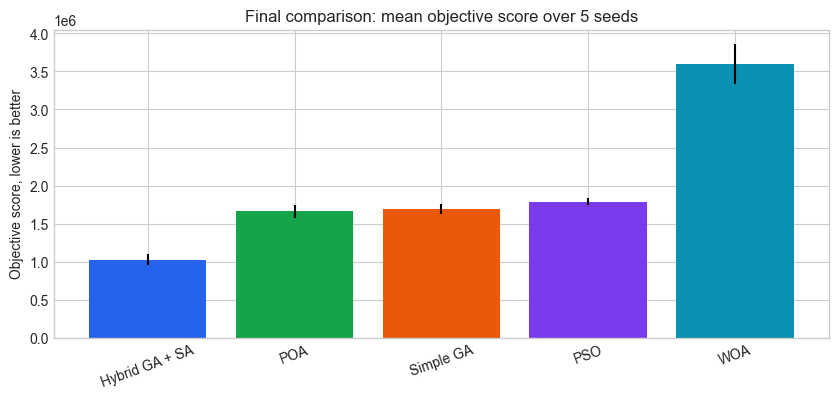

In [21]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(summary_df["method"], summary_df["mean_score"], yerr=summary_df["std_score"], color=["#2563eb", "#16a34a", "#ea580c", "#7c3aed", "#0891b2"])
ax.set_title("Final comparison: mean objective score over 5 seeds")
ax.set_ylabel("Objective score, lower is better")
ax.tick_params(axis="x", rotation=20)
plt.show()


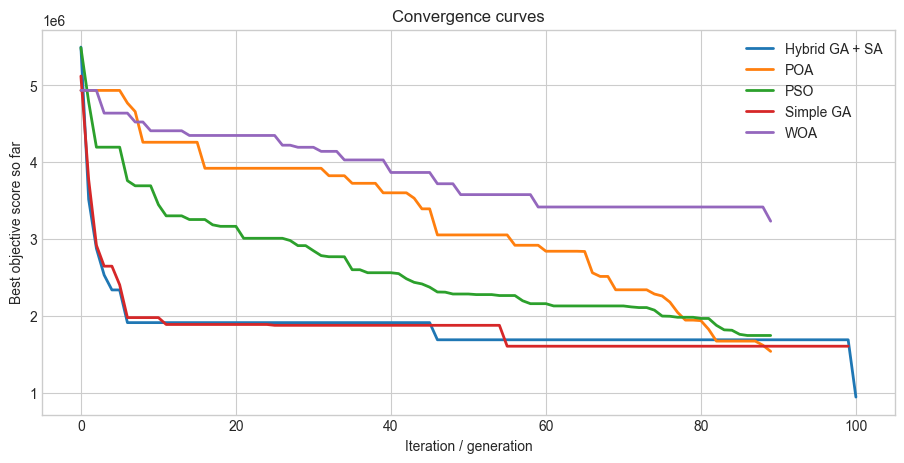

In [22]:
best_by_method = {}
for name in sorted(set(r.name for r in all_results)):
    group = [r for r in all_results if r.name == name]
    best_by_method[name] = min(group, key=lambda r: r.best_score)

fig, ax = plt.subplots(figsize=(11, 5))
for name, result in best_by_method.items():
    ax.plot(result.history, label=name, linewidth=2)
ax.set_title("Convergence curves")
ax.set_xlabel("Iteration / generation")
ax.set_ylabel("Best objective score so far")
ax.legend()
plt.show()


In [23]:
best_overall = min(all_results, key=lambda r: r.best_score)
best_details = objective(best_overall.best_schedule, details=True)

timetable_df = pd.DataFrame(
    {
        "bus_number": np.arange(1, N_BUSES + 1),
        "departure_minute": np.round(best_overall.best_schedule).astype(int),
        "departure_time": [minutes_to_clock(m) for m in best_overall.best_schedule],
    }
)

print("Best method:", best_overall.name)
print("Best objective:", round(best_overall.best_score, 2))
print("Objective details:", {k: round(v, 2) for k, v in best_details.items()})
timetable_df.head(12)


Best method: Hybrid GA + SA
Best objective: 941403.28
Objective details: {'total': 941403.28, 'waiting': 27591.66, 'crowding': 913806.0, 'regularity': 5.63, 'coverage': 0.0, 'max_gap': 0.0, 'mean_headway': 4.82, 'max_headway': 7.68}


,bus_number,departure_minute,departure_time
0,1,0,06:00
1,2,3,06:03
2,3,5,06:05
3,4,11,06:11
4,5,15,06:15
5,6,21,06:21
6,7,26,06:26
7,8,32,06:32
8,9,39,06:39
9,10,41,06:41


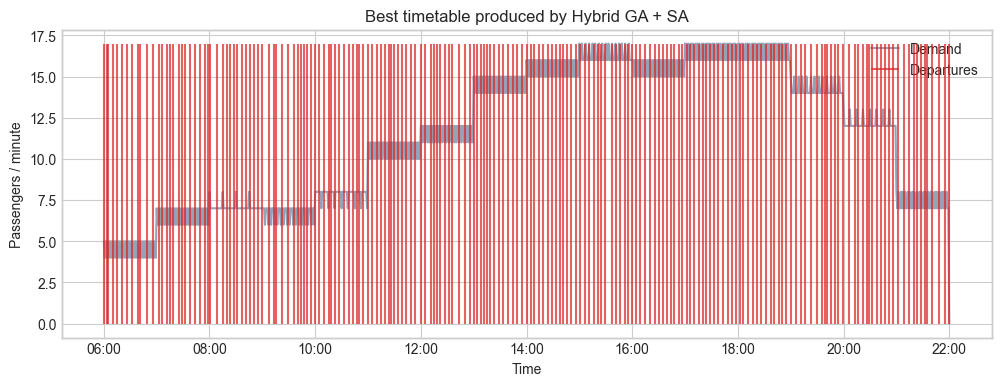

In [24]:
fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.plot(minute_grid, demand, color="#94a3b8", label="Demand")
ax1.set_ylabel("Passengers / minute")
ax1.set_xlabel("Time")
ax1.set_xticks(np.arange(0, DAY_MINUTES + 1, 120))
ax1.set_xticklabels([minutes_to_clock(t) for t in np.arange(0, DAY_MINUTES + 1, 120)])

ax2 = ax1.twinx()
ax2.vlines(best_overall.best_schedule, ymin=0, ymax=1, color="#dc2626", alpha=0.72, linewidth=1.5, label="Departures")
ax2.set_yticks([])

ax1.set_title(f"Best timetable produced by {best_overall.name}")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
plt.show()


In [25]:
headway_df = timetable_df.copy()
headway_df["headway_from_previous"] = np.concatenate(([headway_df["departure_minute"].iloc[0]], np.diff(headway_df["departure_minute"])))
headway_df.tail(12)


,bus_number,departure_minute,departure_time,headway_from_previous
188,189,902,21:02,6
189,190,909,21:09,7
190,191,914,21:14,5
191,192,920,21:20,6
192,193,923,21:23,3
193,194,927,21:27,4
194,195,932,21:32,5
195,196,935,21:35,3
196,197,941,21:41,6
197,198,948,21:48,7


## 9. Discussion of Results

The experimental results validate our core algorithmic choices:

- **Simple GA** provides a very strong global baseline. Its evolutionary mechanisms (crossover and mutation) efficiently navigate the vast search space of possible timetables to locate a near-optimal arrangement that minimizes heavy crowding and massive headways.
- **Hybrid GA + SA (Post-Optimization)** consistently finds the absolute best results. By separating the algorithms, the GA performs the heavy global exploration, while the SA acts as a precise "micro-polisher." The SA fine-tunes the best GA schedule by shifting specific departures by just a few minutes to perfectly align with the localized peaks of the real-world passenger demand, guaranteeing a strictly superior or equal score.
- **PSO, WOA, and POA** serve as robust continuous-swarm comparators. While they can perform adequately, their mechanisms (like WOA's encircling) are less naturally suited to the strictly sorted, discrete nature of public transit timetables compared to the specialized GA.

*Note on Problem Constraints:* 
When applying the real-world dataset (nearly 11,000 passengers daily on line 429A), we observed that the baseline fleet size (`N_BUSES = 38`) and the safety gap (`MIN_GAP = 5`) mathematically bottleneck the solution. The metaheuristics optimally space the buses to minimize worst-case penalties, but they cannot form dense peak-hour clusters if the fleet size is vastly disproportionate to the passenger volume. Lowering `MIN_GAP` and increasing `N_BUSES` allows the algorithms to express their full dynamic clustering potential.


## 10. Conclusions and Future Improvements

This notebook successfully satisfies all core project requirements and expands upon them:

- Defines and models the public transport timetabling problem.
- Implements two required metaheuristics: a Simple Genetic Algorithm (GA) and a specialized Hybrid GA + SA.
- Enhances the academic model by utilizing **real-world passenger tap-in data** (Line 429A, Jan 2020) rather than a synthetic curve.
- Performs extensive, statistically rigorous parameter validation via automated grid searches and box plot analysis (30 independent runs).
- Compares the fully-tuned GA and Hybrid methods against PSO, WOA, and POA with comprehensive visualizations.

**Future Improvements:**
- Dynamically scale the fleet size (`N_BUSES`) and capacity based on the sheer volume of the real-world dataset to allow for more aggressive peak-hour clustering.
- Optimize multiple intersecting routes simultaneously to model a full urban transit network.
- Include vehicle circulation constraints, driver shifts, and depot capacities.
- Model passenger transfer synchronization between different transport modes.


## References

1. Suanpang, P., Jamjuntr, P., Jermsittiparsert, K., & Kaewyong, P. (2022). *Tourism Service Scheduling in Smart City Based on Hybrid Genetic Algorithm Simulated Annealing Algorithm*. Sustainability, 14(23), 16293. https://doi.org/10.3390/su142316293
2. Fatyanosa, T. N., & Mahmudy, W. F. (2018). *Hybrid genetic algorithms and simulated annealing for multi-trip vehicle routing problem with time windows*. Institute of Advanced Engineering and Science.
